In [163]:
import math
import pandas as pd
import numpy as np
import random
import re
import string
from collections import defaultdict
from collections import Counter

In [164]:
splits = {'train': 'train.parquet', 'validation': 'validation.parquet', 'test': 'test.parquet'}

base = "hf://datasets/cornell-movie-review-data/rotten_tomatoes/"
train_df = pd.read_parquet(base + splits['train'])
val_df = pd.read_parquet(base + splits['validation'])
test_df = pd.read_parquet(base + splits['test'])

# Preprocess

In [165]:
def tokenize(text):
    return re.findall(r"\b\w+\b", text.lower().translate(str.maketrans('', '', string.punctuation)))

In [166]:
tokens = [tokenize(t) for t in train_df["text"]]

In [167]:
flat_tokens = [w for sent in tokens for w in sent]
word_counts = Counter(flat_tokens)
vocab = sorted(word_counts.keys())
word_to_id = {w: i for i, w in enumerate(vocab)}
id_to_word = {i: w for w, i in word_to_id.items()}
vocab_size = len(vocab)

# Train word2vec

In [168]:
EMBEDDING_SIZE = 100
CONTEXT_WINDOW_SIZE = 3
NEGATIVES_PER_POSITIVE = 2

In [169]:
def generate_skipgram_pairs(k):
    pairs = set()
    word_context_map = defaultdict(set)
    for sentence in tokens:
        ids = [word_to_id[w] for w in sentence if w in word_to_id]
        for i, center in enumerate(ids):
            # context window
            start = max(0, i - k)
            end = min(len(ids), i + k + 1)
            for j in range(start, end):
                if i == j:
                    continue
                pairs.add((center, ids[j]))
                word_context_map[center].add(ids[j])
    return pairs, word_context_map

In [170]:
pairs, word_context_map = generate_skipgram_pairs(k=CONTEXT_WINDOW_SIZE)

In [171]:
def sample_negative_words(word_idx, n):
    possible_negative_words = set(range(vocab_size)) - word_context_map[word_idx]
    negative_to_select = min(n, len(possible_negative_words))
    return random.sample(sorted(possible_negative_words), negative_to_select)

In [172]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

In [173]:
rng = np.random.default_rng(42)
V_in = rng.uniform(-0.5, 0.5, (vocab_size, EMBEDDING_SIZE))  # input embeddings
U_out = rng.uniform(-0.5, 0.5, (vocab_size, EMBEDDING_SIZE)) # output embeddings

In [174]:
def train_skipgram_vectorized_step(center_id, context_ids: list, lr):
    v_c = V_in[center_id]

    # positive
    U_pos_vec = U_out[context_ids]
    g_pos_vec = (1 - sigmoid(np.dot(U_pos_vec, v_c)))[:, np.newaxis] / len(context_ids)
    grad_v_pos_vec = np.sum(g_pos_vec * U_pos_vec, axis=0)
    U_out[context_ids] += lr * g_pos_vec * v_c[np.newaxis, :]

    # negative
    n_negatives = math.ceil(len(context_ids) * NEGATIVES_PER_POSITIVE)
    neg_ids = list(sample_negative_words(center_id, n_negatives))

    U_neg_vec = U_out[neg_ids]
    g_neg_vec = (-sigmoid(np.dot(U_neg_vec, v_c)))[:, np.newaxis] / len(neg_ids)
    grad_v_neg_vec = np.sum(g_neg_vec * U_neg_vec, axis=0)
    U_out[neg_ids] += lr * g_neg_vec * v_c[np.newaxis, :]

    V_in[center_id] += lr * (grad_v_pos_vec + grad_v_neg_vec)

In [175]:
V_history = []

In [176]:
def train_skipgram_vectorized(lr=0.1, epochs=1):
    for epoch in range(epochs):
        V_history.append(V_in.copy())

        for center, context in word_context_map.items():
            train_skipgram_vectorized_step(center, list(context), lr)
        print(f"Epoch {epoch+1}/{epochs} done")

In [151]:
train_skipgram_vectorized(epochs=50, lr=0.05)
np.save(f"V_in-{EMBEDDING_SIZE}-{CONTEXT_WINDOW_SIZE}.npy", V_in)
np.save(f"U_out-{EMBEDDING_SIZE}-{CONTEXT_WINDOW_SIZE}.npy", U_out)

Epoch 1/50 done
Epoch 2/50 done
Epoch 3/50 done
Epoch 4/50 done
Epoch 5/50 done
Epoch 6/50 done
Epoch 7/50 done
Epoch 8/50 done
Epoch 9/50 done
Epoch 10/50 done
Epoch 11/50 done
Epoch 12/50 done
Epoch 13/50 done
Epoch 14/50 done
Epoch 15/50 done
Epoch 16/50 done
Epoch 17/50 done
Epoch 18/50 done
Epoch 19/50 done
Epoch 20/50 done
Epoch 21/50 done
Epoch 22/50 done
Epoch 23/50 done
Epoch 24/50 done
Epoch 25/50 done
Epoch 26/50 done
Epoch 27/50 done
Epoch 28/50 done
Epoch 29/50 done
Epoch 30/50 done
Epoch 31/50 done
Epoch 32/50 done
Epoch 33/50 done
Epoch 34/50 done
Epoch 35/50 done
Epoch 36/50 done
Epoch 37/50 done
Epoch 38/50 done
Epoch 39/50 done
Epoch 40/50 done
Epoch 41/50 done
Epoch 42/50 done
Epoch 43/50 done
Epoch 44/50 done
Epoch 45/50 done
Epoch 46/50 done
Epoch 47/50 done
Epoch 48/50 done
Epoch 49/50 done
Epoch 50/50 done


In [177]:
V_in = np.load(f"V_in-{EMBEDDING_SIZE}-{CONTEXT_WINDOW_SIZE}.npy")
U_out = np.load(f"U_out-{EMBEDDING_SIZE}-{CONTEXT_WINDOW_SIZE}.npy")

# Sentiment CNN

In [178]:
import os
from tqdm.auto import tqdm
import math
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn.functional as F
from torch.nn.utils.rnn import pad_sequence
import torch.nn as nn

## Prepare vectors for CNN

In [179]:
PAD = "<PAD>"
UNK = "<UNK>"
pad_id = len(word_to_id)
unk_id = pad_id + 1
word_to_id[PAD] = pad_id
word_to_id[UNK] = unk_id

rng = np.random.RandomState(42)
pad_vec = np.zeros((1, EMBEDDING_SIZE), dtype=np.float32)
unk_vec = rng.normal(scale=0.01, size=(1, EMBEDDING_SIZE)).astype(np.float32)
V_in_extended = np.vstack([V_in.astype(np.float32), pad_vec, unk_vec])

In [180]:
class SentimentDataset(Dataset):
    def __init__(self, df, word_to_id, unk_id):
        self.texts = df["text"].tolist()
        self.labels = df["label"].astype(int).tolist()
        self.word_to_id = word_to_id
        self.unk_id = unk_id

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        tokens = tokenize(self.texts[idx])
        ids = [self.word_to_id.get(t, self.unk_id) for t in tokens]
        return torch.tensor(ids, dtype=torch.long), torch.tensor(self.labels[idx], dtype=torch.float32)

def collate_batch(batch):
    ids_list, labels = zip(*batch)
    lengths = torch.tensor([len(x) for x in ids_list], dtype=torch.long)
    if len(ids_list) == 0:
        return torch.empty(0, dtype=torch.long), torch.empty(0)
    padded = pad_sequence(ids_list, batch_first=True, padding_value=pad_id)
    labels = torch.tensor(labels, dtype=torch.float32)
    return padded, lengths, labels

In [181]:
train_ds = SentimentDataset(train_df, word_to_id, unk_id)
val_ds = SentimentDataset(val_df, word_to_id, unk_id)
test_ds = SentimentDataset(test_df, word_to_id, unk_id)

batch_size = 64
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, collate_fn=collate_batch)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, collate_fn=collate_batch)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, collate_fn=collate_batch)

## Train CNN

In [182]:
def evaluate(model, dataloader, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total = 0
    with torch.no_grad():
        for x, lengths, y in dataloader:
            x = x.to(device)
            y = y.to(device)
            logits = model(x)
            loss = criterion(logits, y)
            total_loss += loss.item() * x.size(0)
            preds = (torch.sigmoid(logits) >= 0.5).long()
            total_correct += (preds == y.long()).sum().item()
            total += x.size(0)
    avg_loss = total_loss / total
    acc = total_correct / total
    return avg_loss, acc

def train_epoch(model, dataloader, optimizer, device):
    model.train()
    total_loss = 0.0
    total = 0
    for x, lengths, y in tqdm(dataloader, desc="train"):
        x = x.to(device)
        y = y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5)
        optimizer.step()
        total_loss += loss.item() * x.size(0)
        total += x.size(0)
    return total_loss / total

In [183]:
def select_device():
    if torch.backends.mps.is_available():
        return torch.device("mps")
    elif torch.cuda.is_available():
        return torch.device("cuda")
    else:
        return torch.device("cpu")


device = select_device()

In [200]:
class TextCNN(nn.Module):
    def __init__(self, embed_dim, pretrained_weights, filter_sizes, num_filters, dropout):
        super().__init__()
        emb_tensor = torch.from_numpy(pretrained_weights)
        self.embedding = nn.Embedding.from_pretrained(emb_tensor, freeze=False, padding_idx=pad_id)

        self.filter_sizes = filter_sizes
        self.convs = nn.ModuleList([
            nn.Conv1d(in_channels=embed_dim, out_channels=num_filters, kernel_size=fs)
            for fs in filter_sizes
        ])
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(num_filters * len(filter_sizes), 1)

    def forward(self, x):
        emb = self.embedding(x)
        emb = emb.transpose(1, 2)
        conv_outputs = []
        for conv in self.convs:
            c = conv(emb)
            c = F.relu(c)
            c = F.max_pool1d(c, kernel_size=c.size(2)).squeeze(2)
            conv_outputs.append(c)
        cat = torch.cat(conv_outputs, dim=1)
        dropped = self.dropout(cat)
        logit = self.fc(dropped).squeeze(1)
        return logit


In [207]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# daje troche lepsze wyniki niż TextCNN ze statycznymi embedingami
class TextCNN_TrainableEmbedding(nn.Module):
    def __init__(self, embed_dim, pretrained_weights, filter_sizes, num_filters, dropout):
        super().__init__()

        # Two embeddings: static + trainable
        emb_tensor = torch.from_numpy(pretrained_weights).float()
        self.static_embedding = nn.Embedding.from_pretrained(emb_tensor, freeze=True, padding_idx=pad_id)
        self.trainable_embedding = nn.Embedding.from_pretrained(emb_tensor, freeze=False, padding_idx=pad_id)

        self.filter_sizes = filter_sizes
        self.convs = nn.ModuleList([
            nn.Conv1d(in_channels=embed_dim*2, out_channels=num_filters, kernel_size=fs)
            for fs in filter_sizes
        ])
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(num_filters * len(filter_sizes), 1)

    def forward(self, x):
        static_emb = self.static_embedding(x)
        train_emb = self.trainable_embedding(x)

        emb = torch.cat([static_emb, train_emb], dim=2)
        emb = emb.transpose(1, 2)

        conv_outputs = []
        for conv in self.convs:
            c = F.relu(conv(emb))
            c = F.max_pool1d(c, kernel_size=c.size(2)).squeeze(2)
            conv_outputs.append(c)

        cat = torch.cat(conv_outputs, dim=1)
        dropped = self.dropout(cat)
        logit = self.fc(dropped).squeeze(1)
        return logit

In [208]:
model = TextCNN_TrainableEmbedding(
    embed_dim=V_in_extended.shape[1],
    pretrained_weights=V_in_extended,
    filter_sizes=[2, 3],
    num_filters=32,
    dropout=0.7
).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=5e-3, weight_decay=5e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=1, verbose=True)

In [209]:
best_val_acc = 0.0
history = {"train_loss": [], "val_loss": [], "val_acc": []}
ckpt_dir = "checkpoints"
os.makedirs(ckpt_dir, exist_ok=True)

num_epochs = 20
for epoch in range(1, num_epochs+1):
    train_loss = train_epoch(model, train_loader, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, device)
    scheduler.step(val_acc)  # LR scheduler keyed on val_acc

    print(f"Epoch {epoch}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}, val_acc={val_acc:.4f}")
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    # checkpoint if improved by val_acc
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        ckpt_path = os.path.join(ckpt_dir, f"best_model_epoch{epoch}_acc{val_acc:.4f}.pt")
        torch.save({
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "epoch": epoch,
            "val_acc": val_acc,
        }, ckpt_path)
        print("Saved new best checkpoint:", ckpt_path)

train: 100%|██████████| 134/134 [00:01<00:00, 106.18it/s]


Epoch 1: train_loss=0.6899, val_loss=0.6725, val_acc=0.5957
Saved new best checkpoint: checkpoints/best_model_epoch1_acc0.5957.pt


train: 100%|██████████| 134/134 [00:00<00:00, 135.56it/s]


Epoch 2: train_loss=0.6586, val_loss=0.6402, val_acc=0.6379
Saved new best checkpoint: checkpoints/best_model_epoch2_acc0.6379.pt


train: 100%|██████████| 134/134 [00:00<00:00, 140.10it/s]


...

Epoch 18: train_loss=0.1246, val_loss=0.7579, val_acc=0.7101


train: 100%|██████████| 134/134 [00:00<00:00, 136.84it/s]


Epoch 19: train_loss=0.1179, val_loss=0.7576, val_acc=0.7139


train: 100%|██████████| 134/134 [00:00<00:00, 139.04it/s]

Epoch 20: train_loss=0.1108, val_loss=0.7589, val_acc=0.7129


# Plot metrics history (train vs validation)

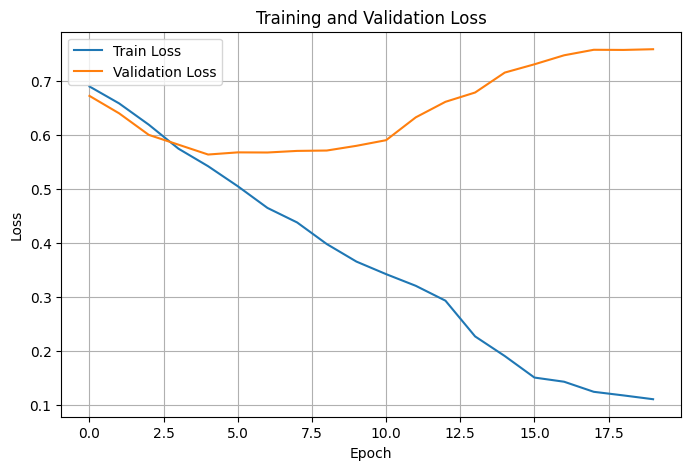

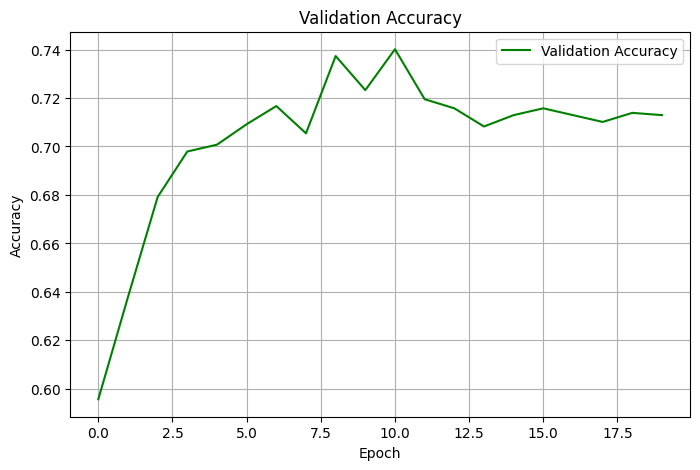

In [210]:
import matplotlib.pyplot as plt

# Plot training & validation loss
plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

# Plot validation accuracy
plt.figure(figsize=(8, 5))
plt.plot(history["val_acc"], label="Validation Accuracy", color="green")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()


# Evaluate best model on test set

In [211]:
checkpoint = torch.load(ckpt_path, map_location=device)

# Restore model and optimizer state
model.load_state_dict(checkpoint["model_state"])
optimizer.load_state_dict(checkpoint["optimizer_state"])

# Optionally restore epoch and val_acc
start_epoch = checkpoint["epoch"]
best_val_acc = checkpoint["val_acc"]

print(f"Loaded checkpoint from epoch {start_epoch} with val_acc={best_val_acc:.4f}")

Loaded checkpoint from epoch 11 with val_acc=0.7402


In [212]:
loss, accuracy = evaluate(model, test_loader, device)
print("loss on test set:", loss)
print("accuracy on test set:", accuracy)

loss on test set: 0.5415523176904468
accuracy on test set: 0.7345215759849906


# Analiza wyników

Z powyźszych wykresów jawnie widać process nadmiernego dopasowania do danych w zbiorze trainingowym, teoretycznie można by to naprawić agresywna regularyzacja oraz dodatkowy dropout, a jednak w praktyce (próby uczenia z różnymi hyper-parametrami) nie dało to znaczącej poprawy.

Najprawdopodobniej spowodowano to niezbyt dużym datasetem oraz niedostatecznym preprocessingiem danych. Przez to architektura CNN w tym przypadku nie pokazuję dobrych wyników (jest nawet gorsze niż przy użyciu naiwnego klasyfikatora bazującego się na `bag-of-words`)